In [13]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [1]:
pip install osmnx

  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)

   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [networkx]
   ---------------------------------------- 0/2 [netwo

In [4]:
import osmnx as ox

rivers = ox.features_from_place("Pune, India", tags={"waterway": "river"})
print(rivers.shape)
print(rivers.columns)

ConnectTimeout: HTTPSConnectionPool(host='overpass-api.de', port=443): Max retries exceeded with url: /api/interpreter (Caused by ConnectTimeoutError(<HTTPSConnection(host='overpass-api.de', port=443) at 0x24f42d439d0>, 'Connection to overpass-api.de timed out. (connect timeout=180)'))

In [6]:
import osmnx as ox

ox.settings.overpass_endpoint = "https://overpass.kumi.systems/api"

rivers = ox.features_from_place("Pune, India", tags={"waterway": "river"})
print(rivers.shape)
print(rivers.columns)

ConnectTimeout: HTTPSConnectionPool(host='overpass-api.de', port=443): Max retries exceeded with url: /api/interpreter (Caused by ConnectTimeoutError(<HTTPSConnection(host='overpass-api.de', port=443) at 0x24f462b1a90>, 'Connection to overpass-api.de timed out. (connect timeout=180)'))

In [14]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Real geometry, from the original fixed source
wards_geom = gpd.read_file("../data/raw/pune_wards.geojson")

# Your saved features/risk scores — plain data, no geometry needed here
features = pd.read_csv("../data/processed/ward_risk_v1.csv")

# Merge them back together on the one column both share
wards = wards_geom.merge(features.drop(columns=["Name2"]), on="wardnum")

print(wards.shape)
print(wards.columns)

(58, 22)
Index(['tessellate_x', 'extrude_x', 'visibility_x', 'wardnum', 'origin_x',
       'Name1_x', 'Name2', 'geometry_x', 'tessellate_y', 'extrude_y',
       'visibility_y', 'origin_y', 'Name1_y', 'geometry_y', 'elevation_mean',
       'dam_discharge_incident_count', 'mean_daily_rainfall',
       'max_daily_rainfall', 'heavy_rain_day_pct', 'elevation_risk',
       'incident_risk', 'risk_score'],
      dtype='str')


In [15]:
new_columns = [
    "wardnum", "elevation_mean", "dam_discharge_incident_count",
    "mean_daily_rainfall", "max_daily_rainfall", "heavy_rain_day_pct",
    "elevation_risk", "incident_risk", "risk_score"
]

wards = wards_geom.merge(features[new_columns], on="wardnum")

print(wards.shape)
print(wards.columns)

(58, 16)
Index(['tessellate', 'extrude', 'visibility', 'wardnum', 'origin', 'Name1',
       'Name2', 'geometry', 'elevation_mean', 'dam_discharge_incident_count',
       'mean_daily_rainfall', 'max_daily_rainfall', 'heavy_rain_day_pct',
       'elevation_risk', 'incident_risk', 'risk_score'],
      dtype='str')


(58, 16)


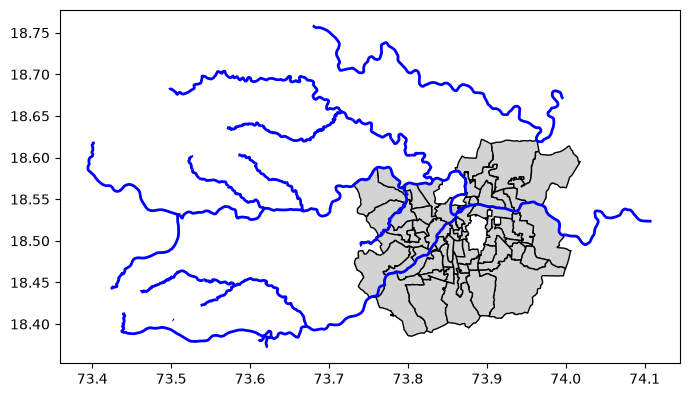

                                Name2  river_distance_m  risk_score
0              Dhanori - Vishrantwadi               0.0    0.347877
3              East Kharadi - Wagholi               0.0    0.358059
5             Vadgaon Sheri - Ramwadi               0.0    0.393182
4        West Kharadi - Vadgaon Sheri               0.0    0.392703
6         Kalyaninagar - Nagpur Chawl               0.0    0.394831
7                  Kalas - Phulenagar               0.0    0.395560
9   Shivajinagar Gaothan - Sangamwadi               0.0    0.396487
8                             Yerwada               0.0    0.393959
12            Baner - Sus - Mahalunge               0.0    0.316014
13                   Pashan - Bawdhan               0.0    0.265836


In [20]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# --- Load base ward geometry + merge in saved risk features ---
wards_geom = gpd.read_file("../data/raw/pune_wards.geojson")
features = pd.read_csv("../data/processed/ward_risk_v1.csv")

new_columns = [
    "wardnum", "elevation_mean", "dam_discharge_incident_count",
    "mean_daily_rainfall", "max_daily_rainfall", "heavy_rain_day_pct",
    "elevation_risk", "incident_risk", "risk_score"
]
wards = wards_geom.merge(features[new_columns], on="wardnum")
print(wards.shape)

# --- Load rivers, visually confirm coverage before trusting it ---
rivers = gpd.read_file("../data/raw/puneriver_v2.geojson")

fig, ax = plt.subplots(figsize=(8, 8))
wards.plot(ax=ax, color="lightgrey", edgecolor="black")
rivers.plot(ax=ax, color="blue", linewidth=2)
plt.show()

# --- Reproject both to a real metric CRS (UTM 43N) before measuring distance ---
wards_utm = wards.to_crs(epsg=32643)
rivers_utm = rivers.to_crs(epsg=32643)

# --- Combine all river segments into one shape, then get distance per ward ---
river_union = rivers_utm.union_all()
wards["river_distance_m"] = wards_utm.distance(river_union)

# --- Sanity check: known flood wards should be closest to the river ---
print(wards.sort_values("river_distance_m")[["Name2", "river_distance_m", "risk_score"]].head(10))

In [21]:
print(wards_utm.crs)
print(rivers_utm.crs)
print(river_union.bounds)
print(wards_utm.total_bounds)

EPSG:32643
EPSG:32643
(330592.5670665421, 2031902.9757963785, 405935.4393120501, 2074595.8182892378)
[ 366148.15924221 2033239.73524761  396432.96853203 2059346.87509664]


In [22]:
print(wards[wards["wardnum"].isin([34, 35, 52])][["Name2", "wardnum", "river_distance_m"]])

                            Name2  wardnum  river_distance_m
32        Warje - Kondhave Dhavde       34               0.0
33  Ramnagar - Uttamnagar Shivane       35               0.0
50         Nanded City - Sun City       52               0.0
